<a href="https://colab.research.google.com/github/Yeabebe/ZX-CENF/blob/feature%2Fbialgebra-rewrite/experiments/zx_bialgebra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ZX-Calculus Bialgebra Rewrite

A mathematically motivated implementation of the ZX-calculus
bialgebra rewrite rule using NetworkX.

Representation:
- Nodes represent Z/X spiders
- Node attributes:
    - color
    - phase

- Edges represent:
    - normal connections
    - Hadamard connections

Imports

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import itertools
import copy


# Spider colors

Z = "Z"
X = "X"


# Edge types

NORMAL = "normal"
HADAMARD = "hadamard"

ZXGraph Class

In [2]:
class ZXGraph:

    def __init__(self):

        self.graph = nx.Graph()

        self.node_counter = 0



    def add_spider(
        self,
        color,
        phase=0
    ):

        node = self.node_counter

        self.node_counter += 1


        self.graph.add_node(
            node,
            color=color,
            phase=phase
        )


        return node



    def add_edge(
        self,
        u,
        v,
        edge_type=NORMAL
    ):

        self.graph.add_edge(
            u,
            v,
            type=edge_type
        )



    def remove_node(
        self,
        node
    ):

        self.graph.remove_node(node)



    def color(
        self,
        node
    ):

        return self.graph.nodes[node]["color"]



    def phase(
        self,
        node
    ):

        return self.graph.nodes[node]["phase"]



    def edge_type(
        self,
        u,
        v
    ):

        return self.graph.edges[u,v]["type"]

Visualization

In [3]:
def draw_zx(
    zx,
    title="ZX Diagram"
):

    plt.figure(figsize=(6,5))


    pos = nx.spring_layout(
        zx.graph,
        seed=10
    )


    node_colors=[]


    for n in zx.graph.nodes:

        if zx.color(n)==Z:
            node_colors.append("green")

        else:
            node_colors.append("red")



    nx.draw_networkx_nodes(
        zx.graph,
        pos,
        node_color=node_colors,
        node_size=1200
    )


    nx.draw_networkx_labels(
        zx.graph,
        pos,
        labels={
            n:
            f"{zx.color(n)}\n{zx.phase(n)}"
            for n in zx.graph.nodes
        }
    )


    normal_edges=[]
    had_edges=[]


    for u,v,data in zx.graph.edges(data=True):

        if data["type"]==NORMAL:
            normal_edges.append((u,v))

        else:
            had_edges.append((u,v))



    nx.draw_networkx_edges(
        zx.graph,
        pos,
        edgelist=normal_edges
    )


    nx.draw_networkx_edges(
        zx.graph,
        pos,
        edgelist=had_edges,
        style="dashed"
    )


    plt.title(title)

    plt.axis("off")

    plt.show()

Basic ZX Utilities

In [4]:
def opposite_color(
    c1,
    c2
):

    return (
        (c1==Z and c2==X)
        or
        (c1==X and c2==Z)
    )



def zero_phase(
    zx,
    node
):

    return zx.phase(node)==0



def normal_connection(
    zx,
    u,
    v
):

    return (
        zx.edge_type(u,v)
        ==
        NORMAL
    )

Pattern Detection

In [5]:
def find_bialgebra_candidates(
    zx
):

    candidates=[]


    for center in zx.graph.nodes:


        neighbors=list(
            zx.graph.neighbors(center)
        )


        if len(neighbors)<2:
            continue



        for a,b in itertools.combinations(
            neighbors,
            2
        ):


            if zx.color(a)!=zx.color(b):
                continue



            if not opposite_color(
                zx.color(center),
                zx.color(a)
            ):
                continue



            candidates.append(
                {
                    "center":center,
                    "outer":[a,b]
                }
            )


    return candidates

Validation

In [6]:
def validate_bialgebra(
    zx,
    pattern
):

    center=pattern["center"]

    a,b=pattern["outer"]



    nodes=[
        center,
        a,
        b
    ]


    # zero phases

    for n in nodes:

        if not zero_phase(
            zx,
            n
        ):
            return False



    # colors

    if not opposite_color(
        zx.color(center),
        zx.color(a)
    ):
        return False



    if zx.color(a)!=zx.color(b):
        return False



    # edge types

    if not normal_connection(
        zx,
        center,
        a
    ):
        return False



    if not normal_connection(
        zx,
        center,
        b
    ):
        return False



    return True

Bialgebra Rewrite Function

In [7]:
def apply_bialgebra(
    zx,
    pattern
):

    if not validate_bialgebra(
        zx,
        pattern
    ):
        return False


    center = pattern["center"]

    a, b = pattern["outer"]


    center_color = zx.color(center)

    outer_color = zx.color(a)


    #
    # Create equivalent bialgebra-expanded spiders
    #

    new_center = zx.add_spider(
        outer_color,
        0
    )


    new_outer = zx.add_spider(
        center_color,
        0
    )


    #
    # Preserve external connections
    #

    external_connections = []


    for node in [a, b]:

        for neighbor in list(
            zx.graph.neighbors(node)
        ):

            if neighbor != center:

                edge = zx.edge_type(
                    node,
                    neighbor
                )

                external_connections.append(
                    (
                        node,
                        neighbor,
                        edge
                    )
                )


    #
    # Remove old local structure
    #

    zx.remove_node(center)



    #
    # Connect new bialgebra structure
    #

    zx.add_edge(
        new_center,
        new_outer,
        NORMAL
    )


    zx.add_edge(
        new_center,
        a,
        NORMAL
    )


    zx.add_edge(
        new_center,
        b,
        NORMAL
    )


    #
    # Restore external edges
    #

    for old, neighbor, edge_type in external_connections:

        if neighbor in zx.graph:

            zx.add_edge(
                old,
                neighbor,
                edge_type
            )


    return True

Create Bialgebra Test Example

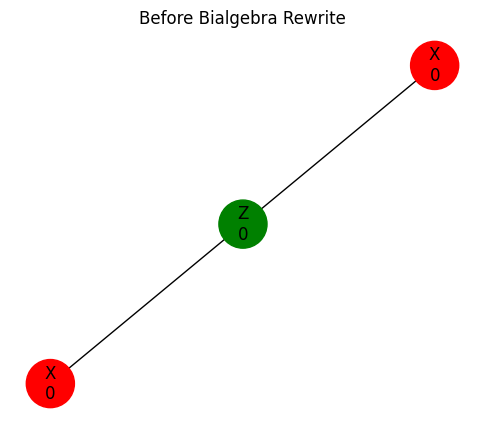

In [8]:
zx = ZXGraph()


z = zx.add_spider(
    Z,
    0
)


x1 = zx.add_spider(
    X,
    0
)


x2 = zx.add_spider(
    X,
    0
)



zx.add_edge(
    z,
    x1,
    NORMAL
)


zx.add_edge(
    z,
    x2,
    NORMAL
)



draw_zx(
    zx,
    "Before Bialgebra Rewrite"
)

Detect and Apply Rewrite

Candidates: 1


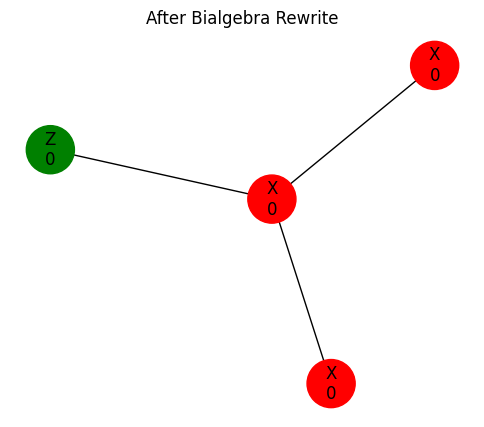

In [9]:
patterns = find_bialgebra_candidates(
    zx
)


print(
    "Candidates:",
    len(patterns)
)



for pattern in patterns:

    if validate_bialgebra(
        zx,
        pattern
    ):

        apply_bialgebra(
            zx,
            pattern
        )

        break



draw_zx(
    zx,
    "After Bialgebra Rewrite"
)

Multiple Rewrite Application

In [10]:
def apply_all_bialgebra(
    zx,
    max_iterations=50
):

    count = 0


    for _ in range(max_iterations):

        patterns = find_bialgebra_candidates(
            zx
        )


        applied = False


        for pattern in patterns:


            if validate_bialgebra(
                zx,
                pattern
            ):

                if apply_bialgebra(
                    zx,
                    pattern
                ):

                    count += 1

                    applied = True

                    break



        if not applied:

            break


    return count

Rewrite Test

Before: 3
Rewrites: 1
After: 4


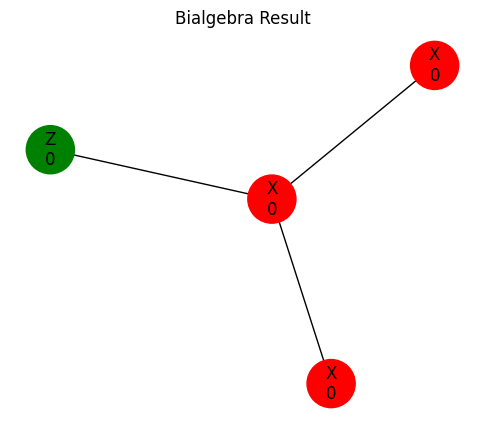

In [11]:
zx_test = ZXGraph()


z = zx_test.add_spider(
    Z,
    0
)

x1 = zx_test.add_spider(
    X,
    0
)

x2 = zx_test.add_spider(
    X,
    0
)



zx_test.add_edge(
    z,
    x1,
    NORMAL
)

zx_test.add_edge(
    z,
    x2,
    NORMAL
)



print(
    "Before:",
    zx_test.graph.number_of_nodes()
)


rewrites = apply_all_bialgebra(
    zx_test
)



print(
    "Rewrites:",
    rewrites
)


print(
    "After:",
    zx_test.graph.number_of_nodes()
)



draw_zx(
    zx_test,
    "Bialgebra Result"
)

Experiment Report Helper

In [12]:
def graph_summary(zx):

    return {
        "nodes": zx.graph.number_of_nodes(),
        "edges": zx.graph.number_of_edges()
    }



def bialgebra_experiment_report(
    before,
    after,
    patterns,
    validation,
    applied
):

    print(
        "ZX Bialgebra Rewrite Experiment"
    )

    print(
        "-"*31
    )

    print()


    print(
        "Input graph:"
    )

    print(
        f"- Nodes: {before['nodes']}"
    )

    print(
        f"- Edges: {before['edges']}"
    )


    print()


    print(
        "Detected patterns:"
    )

    print(
        f"- {len(patterns)}"
    )


    print()


    print(
        "Validation:"
    )


    if validation:
        print(
            "- Passed"
        )

    else:
        print(
            "- Failed"
        )


    print()


    print(
        "Rewrite:"
    )


    if applied:

        print(
            "- Applied successfully"
        )

    else:

        print(
            "- Not applied"
        )


    print()


    print(
        "Output graph:"
    )

    print(
        f"- Nodes: {after['nodes']}"
    )

    print(
        f"- Edges: {after['edges']}"
    )


    print()


    print(
        "Status:"
    )


    if applied and validation:

        print(
            "- Successful bialgebra transformation"
        )

    else:

        print(
            "- Failed transformation"
        )

Run Experiment With Report

In [13]:
zx_exp = ZXGraph()


z = zx_exp.add_spider(
    Z,
    0
)


x1 = zx_exp.add_spider(
    X,
    0
)


x2 = zx_exp.add_spider(
    X,
    0
)


zx_exp.add_edge(
    z,
    x1,
    NORMAL
)


zx_exp.add_edge(
    z,
    x2,
    NORMAL
)



before = graph_summary(
    zx_exp
)



patterns = find_bialgebra_candidates(
    zx_exp
)



validation = False
applied = False



if len(patterns)>0:

    validation = validate_bialgebra(
        zx_exp,
        patterns[0]
    )


    if validation:

        applied = apply_bialgebra(
            zx_exp,
            patterns[0]
        )



after = graph_summary(
    zx_exp
)



bialgebra_experiment_report(
    before,
    after,
    patterns,
    validation,
    applied
)

ZX Bialgebra Rewrite Experiment
-------------------------------

Input graph:
- Nodes: 3
- Edges: 2

Detected patterns:
- 1

Validation:
- Passed

Rewrite:
- Applied successfully

Output graph:
- Nodes: 4
- Edges: 3

Status:
- Successful bialgebra transformation
